<a href="https://colab.research.google.com/github/DarleneJD/ACOPF/blob/main/CurvasVoltVarTrifasico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DATA: 13/03/2026**
**REDE: 13 BARRAS DE BAIXA TENSÃO TRIFÁSICA DESBALANCEADA**

**FUNÇÃO:** avaliar o sistema com controle Volt-Var por meio da curva dos inversores.

**CURVA:** curva geral IEEE 1547.

**OBJETIVO:** minimizar as perdas elétricas por meio da função objetivo.

### **MODELO TRIFÁSICO DESBALANCEADO**

Rede radial de baixa tensão com 5 barras (400 V / 250 kVA), conectada a uma rede de média tensão de 20 kV por meio de um transformador. O sistema é modelado como **trifásico desbalanceado por fase**, de modo que cada barra possui variáveis elétricas independentes para as fases (a), (b) e (c), permitindo representar explicitamente assimetrias de carga, geração fotovoltaica e tensão.

As barras 1, 2 e 4 possuem **carga e geração fotovoltaica trifásicas**, com a potência total dividida igualmente entre as três fases. As barras 3 e 5 possuem **carga e geração fotovoltaica monofásicas**, conectadas a uma fase específica, enquanto as demais fases dessas barras permanecem sem injeção de potência ativa e reativa associada a esses elementos.

O problema é formulado como um **OPF (Optimal Power Flow)** na forma de **MINLP**, implementado em **Pyomo** e resolvido com o **BONMIN**. A modelagem elétrica utiliza equações do tipo **DistFlow por fase**, com variáveis de fluxo ativo, fluxo reativo, corrente ao quadrado e magnitude de tensão ao quadrado para cada ramo e fase da rede. Nesta formulação, cada fase é representada separadamente, permitindo capturar o comportamento desbalanceado do sistema.

A **função objetivo** minimiza as **perdas totais ativas da rede**, calculadas pela soma das perdas em todos os ramos e em todas as fases.

O controle **Volt-Var**, conforme a **IEEE 1547-2018**, é implementado **por barra e por fase**, ou seja, cada inversor responde à tensão local da fase à qual está conectado. A curva Volt-Var é representada com variáveis binárias e restrições do tipo **Big-M**, considerando cinco regiões operativas delimitadas pelos pontos:

* ($V_{1}$ = 0.92) pu
* ($V_{2}$ = 0.98) pu
* ($V_{3}$ = 1.02) pu
* ($V_{4}$ = 1.08) pu

Com isso, cada unidade fotovoltaica pode injetar ou absorver potência reativa de acordo com a tensão local da fase, respeitando seus limites de capacidade reativa.

As bases adotadas no sistema são:

* **potência base trifásica:** ($S_{base}$ = 250 kVA)
* **potência base por fase:** ($S_{base,1\phi}$ = $\frac{250}{3}$ kVA)
* **tensão base na baixa tensão:** ($V_{base}$ = 400  V) fase-fase

Nesta versão, o modelo representa a rede como **trifásica desbalanceada por fase**, com controle Volt-Var individual por fase, tornando a formulação coerente com a presença simultânea de elementos trifásicos e monofásicos ao longo do alimentador.



# Bibliotecas




In [1]:
%%capture
import sys
import os

if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'


In [2]:
# import shutil
# import sys
# import os.path

# if not shutil.which("pyomo"):
#     !pip install -q pyomo
#     assert(shutil.which("pyomo"))

# if not (shutil.which("ipopt") or os.path.isfile("ipopt")):
#     if "google.colab" in sys.modules:
#         !wget -N -q "https://matematica.unipv.it/gualandi/solvers/ipopt-linux64.zip"
#         !unzip -o -q ipopt-linux64
#     else:
#         try:
#             !conda install -c conda-forge ipopt
#         except:
#             pass


In [9]:
!rm -rf ACOPF
!git clone https://github.com/DarleneJD/ACOPF.git

Cloning into 'ACOPF'...
remote: Enumerating objects: 202, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 202 (delta 26), reused 0 (delta 0), pack-reused 153 (from 1)
Receiving objects: 100% (202/202), 1.48 MiB | 8.43 MiB/s, done.
Resolving deltas: 100% (117/117), done.


In [5]:
import sys
import os
from re import I
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt



Getting files...
Done
-----------------------------------------------------------------
IDAES Extensions Build Versions
Solvers:  v3.4.2 20240811 ubuntu2204-x86_64
Library:  v3.4.2 20240811 ubuntu2204-x86_64



# Dados de entrada

In [67]:

# ============================================================
# LEITURA
# ============================================================
base_path = "/content/ACOPF"
controle = f"{base_path}/volt-var.xlsx"

df_bus_bt = pd.read_excel(controle, sheet_name="bus_BT")
df_pv_bt = pd.read_excel(controle, sheet_name="bus_PV")
df_branches_bt = pd.read_excel(controle, sheet_name="branches_BT")


In [68]:

# padronização de colunas
df_bus_bt.columns = df_bus_bt.columns.str.strip()
df_pv_bt.columns = df_pv_bt.columns.str.strip()
df_branches_bt.columns = df_branches_bt.columns.str.strip()

# ============================================================
# CONSTANTES GERAIS
# ============================================================
PHASES = ["a", "b", "c"]
PHASE_MAP = {"1": "a", "2": "b", "3": "c"}

SLACK_BUS = "SOURCE"

FP_CARGA = 0.9
ANGULO_CARGA = np.arccos(FP_CARGA)

V_SLACK_PU = 1.02
vmin, vmax = 0.90, 1.20

FATOR_CARGA = 0.5
FATOR_PV = 1.0

# curva Volt-Var
V1, V2, V3, V4 = 0.92, 0.98, 1.02, 1.08
V1_2, V2_2, V3_2, V4_2 = V1**2, V2**2, V3**2, V4**2
M_bigm = 5.0

# base elétrica
PERCENT_R_TRAFO = 1.91
PERCENT_X_TRAFO = 3.51
S_base_3ph = 250.0
S_base_1ph = S_base_3ph / 3.0

# ============================================================
# FUNÇÕES AUXILIARES
# ============================================================
def parse_conn(phases_value):
    """
    Retorna:
    - conn_type: 'three_phase' ou 'single_phase'
    - conn_phase: 'a','b','c' ou None
    """
    s = str(phases_value).strip()

    if s == "1,2,3":
        return "three_phase", None
    if s in PHASE_MAP:
        return "single_phase", PHASE_MAP[s]

    raise ValueError(f"Valor inválido em 'phases': {phases_value}")


def safe_float(x, default=0.0):
    if pd.isna(x):
        return default
    return float(x)


def dividir_carga_por_fase(total_kw, bus, phase):
    """
    Divide carga agregada da barra por fase.
    """
    bus_type = BUS_TYPE[bus]
    bus_phase = BUS_PHASE[bus]

    if bus_type == "three_phase":
        return total_kw / 3.0
    if bus_type == "single_phase":
        return total_kw if phase == bus_phase else 0.0

    raise ValueError(f"Tipo de barra inválido: {bus}")


def calc_limites_qpv_por_fase(bus, phase, p_pv_1f_kw):
    """
    Limites Q do inversor por fase, em kVAr.
    Usa os dados já carregados por barra-fase.
    """
    p_nom_1f = P_PV_NOMINAL.get((bus, phase), 0.0)
    q_nom_1f = Q_PV_RATED.get((bus, phase), 0.0)
    s_nom_1f = S_PV_NOMINAL.get((bus, phase), 0.0)

    if p_nom_1f <= 1e-12 or q_nom_1f <= 1e-12 or s_nom_1f <= 1e-12:
        return 0.0, 0.0

    p1 = 0.05 * p_nom_1f
    p2 = 0.20 * p_nom_1f

    if p_pv_1f_kw < p1:
        qmax = 0.0
    elif p_pv_1f_kw >= p2:
        qmax = q_nom_1f
    else:
        qmax = 2.2 * s_nom_1f * (p_pv_1f_kw / p_nom_1f)

    return -qmax, qmax

In [52]:
# Padronização das fases,
def parse_conn(phases_value):
    """
    Converte a coluna 'phases' para:
    - conn_type: 'three_phase' ou 'single_phase'
    - conn_phase: 'a','b','c' ou None
    """
    s = str(phases_value).strip()

    if s == "1,2,3":
        return "three_phase", None

    if s in PHASE_MAP:
        return "single_phase", PHASE_MAP[s]

    raise ValueError(f"Valor inválido em 'phases': {phases_value}")


def safe_float(x, default=0.0):
    if pd.isna(x):
        return default
    return float(x)

### BUS BT

In [69]:
# ============================================================
# BARRAS BT
# ============================================================
BUS_NAME_TO_N = {}
BUS_N_TO_NAME = {}

BUS_TYPE = {}
BUS_PHASE = {}
V_NOM_KV_FN = {}

P_CARGA_NOMINAL_BARRA = {}
Q_CARGA_NOMINAL_BARRA = {}

buses_bt = []

for _, row in df_bus_bt.iterrows():
    bus_n = int(row["N"])
    bus_name = str(row["name"]).strip()

    conn_type, conn_phase = parse_conn(row["phases"])

    BUS_NAME_TO_N[bus_name] = bus_n
    BUS_N_TO_NAME[bus_n] = bus_name

    BUS_TYPE[bus_name] = conn_type
    BUS_PHASE[bus_name] = conn_phase
    V_NOM_KV_FN[bus_name] = safe_float(row["v_nom_kv"])

    P_CARGA_NOMINAL_BARRA[bus_name] = safe_float(row["P_D"])
    Q_CARGA_NOMINAL_BARRA[bus_name] = safe_float(row["Q_D"])

    buses_bt.append(bus_name)

buses_bt = sorted(set(buses_bt))

### Planilha PV

In [70]:
# ============================================================
# PV POR BARRA-FASE
# ============================================================
df_pv_bt["Bus"] = df_pv_bt["Bus"].astype(str).str.strip()
df_pv_bt["phases"] = df_pv_bt["phases"].astype(str).str.strip()

PV_TYPE = {}
PV_PHASE = {}

P_PV_NOMINAL = {}
Q_PV_RATED = {}
S_PV_NOMINAL = {}

# inicializa todas as barras/fases com zero
for bus in buses_bt:
    PV_TYPE[bus] = None
    PV_PHASE[bus] = None
    for ph in PHASES:
        P_PV_NOMINAL[(bus, ph)] = 0.0
        Q_PV_RATED[(bus, ph)] = 0.0
        S_PV_NOMINAL[(bus, ph)] = 0.0

# sobrescreve onde houver PV
for _, row in df_pv_bt.iterrows():
    bus = row["Bus"]
    conn_type, conn_phase = parse_conn(row["phases"])

    PV_TYPE[bus] = conn_type
    PV_PHASE[bus] = conn_phase

    kva_total = safe_float(row["kva"])

    p_by_phase = {
        "a": safe_float(row["p_pv_1"]),
        "b": safe_float(row["p_pv_2"]),
        "c": safe_float(row["p_pv_3"]),
    }

    q_by_phase = {
        "a": safe_float(row["q_pv_1"]),
        "b": safe_float(row["q_pv_2"]),
        "c": safe_float(row["q_pv_3"]),
    }

    if conn_type == "three_phase":
        for ph in PHASES:
            P_PV_NOMINAL[(bus, ph)] = p_by_phase[ph]
            Q_PV_RATED[(bus, ph)] = q_by_phase[ph]
            S_PV_NOMINAL[(bus, ph)] = kva_total / 3.0
    else:
        for ph in PHASES:
            if ph == conn_phase:
                P_PV_NOMINAL[(bus, ph)] = p_by_phase[ph]
                Q_PV_RATED[(bus, ph)] = q_by_phase[ph]
                S_PV_NOMINAL[(bus, ph)] = kva_total

### Branches

In [55]:
LINES_BT = []
BRANCH_TYPE = {}
BRANCH_PHASE = {}
R_LINE = {}
X_LINE = {}
IMAX_LINE = {}
LENGTH_M = {}

for _, row in df_branches_bt.iterrows():
    from_bus = str(row["l"]).strip()
    to_bus   = str(row["k"]).strip()

    conn_type, conn_phase = parse_conn(row["phase"])

    LINES_BT.append((from_bus, to_bus))

    BRANCH_TYPE[(from_bus, to_bus)] = conn_type
    BRANCH_PHASE[(from_bus, to_bus)] = conn_phase

    R_LINE[(from_bus, to_bus)] = safe_float(row["R"])
    X_LINE[(from_bus, to_bus)] = safe_float(row["X"])
    IMAX_LINE[(from_bus, to_bus)] = safe_float(row["Imax"])
    LENGTH_M[(from_bus, to_bus)] = safe_float(row["Length_m"])

LINES_BT = list(dict.fromkeys(LINES_BT))

### Identificar os troncos

In [56]:
from_set = {i for i, j in LINES_BT}
to_set   = {j for i, j in LINES_BT}

ROOTS_BT = sorted(from_set - to_set)
print("Raízes BT:", ROOTS_BT)

Raízes BT: ['B010', 'B020', 'B030', 'B040', 'B050', 'B060', 'B070', 'B080', 'B090', 'B100', 'B110']


### Conexões jusante e montante

In [57]:
SLACK_BUS = "SOURCE"

TRAFO_CONN = [(SLACK_BUS, root) for root in ROOTS_BT]
ALL_CONN = TRAFO_CONN + LINES_BT

In [58]:
UPSTREAM = {}
DOWNSTREAM = {bus: [] for bus in buses_bt}
DOWNSTREAM[SLACK_BUS] = []

for i, j in LINES_BT:
    UPSTREAM[j] = (i, j)
    DOWNSTREAM[i].append((i, j))

for root in ROOTS_BT:
    UPSTREAM[root] = (SLACK_BUS, root)
    DOWNSTREAM[SLACK_BUS].append((SLACK_BUS, root))

In [59]:
PERCENT_R_TRAFO = 1.91
PERCENT_X_TRAFO = 3.51

# base
S_base_3ph = 250.0 # verificar isso
S_base_1ph = S_base_3ph / 3.0

# usar tensão BT fase-fase
V_BT_LL = 0.48 * np.sqrt(3)   # se 0.48 kV for fase-neutro
Z_base_Ohm = ((V_BT_LL ** 2) / S_base_3ph) * 1000

R_TRAFO_Ohm = (PERCENT_R_TRAFO / 100.0) * Z_base_Ohm
X_TRAFO_Ohm = (PERCENT_X_TRAFO / 100.0) * Z_base_Ohm

R_TRAFO_1ph_Ohm = R_TRAFO_Ohm / 3.0
X_TRAFO_1ph_Ohm = X_TRAFO_Ohm / 3.0

R_TRAFO_pu = R_TRAFO_1ph_Ohm / Z_base_Ohm
X_TRAFO_pu = X_TRAFO_1ph_Ohm / Z_base_Ohm

# R, X para pu
R_LINE_PU = {k: v / Z_base_Ohm for k, v in R_LINE.items()}
X_LINE_PU = {k: v / Z_base_Ohm for k, v in X_LINE.items()}

# Completar R e X com as conexões do slack
R_CONN_PU = dict(R_LINE_PU)
X_CONN_PU = dict(X_LINE_PU)

for root in ROOTS_BT:
    R_CONN_PU[(SLACK_BUS, root)] = R_TRAFO_pu
    X_CONN_PU[(SLACK_BUS, root)] = X_TRAFO_pu

# Máscara fases existentes
# Barras
def phase_exists_bus(bus, ph):
    if bus == SLACK_BUS:
        return True
    if BUS_TYPE[bus] == "three_phase":
        return True
    return BUS_PHASE[bus] == ph
# Ramos
def phase_exists_branch(i, j, ph):
    if (i, j) in TRAFO_CONN:
        return True
    if BRANCH_TYPE[(i, j)] == "three_phase":
        return True
    return BRANCH_PHASE[(i, j)] == ph

In [60]:
print("=" * 70)
print("SISTEMA TRIFÁSICO DESBALANCEADO POR FASE")
print("=" * 70)
print(f"V_BT_FF = {V_BT_LL*1000:.0f} V |")
print(f"S_base_3f = {S_base_3ph:.2f} kVA | S_base_1f = {S_base_1ph:.4f} kVA")
print(f"Z_base = {Z_base_Ohm:.4f} ohm")
print(f"R_TRAFO_pu = {R_TRAFO_pu:.6f}")
print(f"X_TRAFO_pu = {X_TRAFO_pu:.6f}")
print(f"R_LINE_PU = {R_LINE_PU}")
print(f"X_LINE_PU = {X_LINE_PU}")

SISTEMA TRIFÁSICO DESBALANCEADO POR FASE
V_BT_FF = 831 V |
S_base_3f = 250.00 kVA | S_base_1f = 83.3333 kVA
Z_base = 2.7648 ohm
R_TRAFO_pu = 0.006367
X_TRAFO_pu = 0.011700
R_LINE_PU = {('B010', 'B011'): np.float64(0.0006872106481481484), ('B011', 'B012'): np.float64(0.0006872106481481484), ('B012', 'B013'): np.float64(0.0006872106481481484), ('B013', 'B014'): np.float64(0.0006872106481481484), ('B020', 'B021'): np.float64(0.0006872106481481484), ('B021', 'B022'): np.float64(0.0006872106481481484), ('B022', 'B023'): np.float64(0.0006872106481481484), ('B023', 'B024'): np.float64(0.0006872106481481484), ('B030', 'B031'): np.float64(0.0006872106481481484), ('B031', 'B032'): np.float64(0.0006872106481481484), ('B032', 'B033'): np.float64(0.0006872106481481484), ('B033', 'B034'): np.float64(0.0006872106481481484), ('B040', 'B041'): np.float64(0.0006872106481481484), ('B041', 'B042'): np.float64(0.0006872106481481484), ('B042', 'B043'): np.float64(0.0006872106481481484), ('B043', 'B044'): np

In [61]:
P_CARGA_NOMINAL_BARRA = {}
Q_CARGA_NOMINAL_BARRA = {}
BUS_TYPE = {}
BUS_PHASE = {}

for _, row in df_bus_bt.iterrows():
    barra = str(row["name"]).strip()

    phases_str = str(row["phases"]).strip()
    bus_type = infer_type(phases_str)
    bus_phase = infer_phase(phases_str)

    BUS_TYPE[barra] = bus_type
    BUS_PHASE[barra] = bus_phase

    P_CARGA_NOMINAL_BARRA[barra] = float(row["P_D"]) if pd.notna(row["P_D"]) else 0.0
    Q_CARGA_NOMINAL_BARRA[barra] = float(row["Q_D"]) if pd.notna(row["Q_D"]) else 0.0

In [66]:
resultados_lista = []
FP_CARGA = 0.9
ANGULO_CARGA = np.arccos(FP_CARGA)
V_SLACK_PU = 1.02
vmin, vmax = 0.90, 1.20
FATOR_CARGA = 0.5
FATOR_FV = 1.0

for _, linha in df_pv_bt.iterrows():


    # ------------------------------------------------------------
    # PARÂMETROS POR BARRA-FASE
    # ------------------------------------------------------------

    P_pv_fase    = {}
    Qmax_fase    = {}
    Qmin_fase    = {}

    for barra in df_bus_bt:
        # carga total da barra vinda da planilha bus_BT
        p_carga_total = P_CARGA_NOMINAL_BARRA.get(barra, 0.0) * FATOR_CARGA
        q_carga_total = Q_CARGA_NOMINAL_BARRA.get(barra, 0.0) * FATOR_CARGA

        print(f"\nBarra {barra}")

        for fase in PHASES:
            # -----------------------------
            # CARGA
            # -----------------------------
            # p_carga_1f = dividir_carga_por_fase(p_carga_total, barra, fase)
            # q_carga_1f = dividir_carga_por_fase(q_carga_total, barra, fase)

            P_carga_fase[(barra, fase)] = p_carga_1f / S_base_1f
            Q_carga_fase[(barra, fase)] = q_carga_1f / S_base_1f

            # -----------------------------
            # PV
            # já vem por fase da planilha
            # -----------------------------
            p_pv_nom_1f = P_PV_NOMINAL.get((barra, fase), 0.0)
            p_pv_1f = p_pv_nom_1f * FATOR_PV
            P_pv_fase[(barra, fase)] = p_pv_1f / S_base_1f

            qmin_1f, qmax_1f = calc_limites_qpv_por_fase(barra, fase, p_pv_1f)
            Qmin_fase[(barra, fase)] = qmin_1f / S_base_1f
            Qmax_fase[(barra, fase)] = qmax_1f / S_base_1f

            print(
                f"  fase {fase}: "
                f"Pcarga={P_CARGA_NOMINAL_BARRA:8.3f} kW | "
                f"Qcarga={q_CARGA_NOMINAL_BARRA:8.3f} kVAr | "
                f"Ppv={p_pv_1f:8.3f} kW | "
                f"Qpv±={qmax_1f:8.3f} kVAr"
            )


Barra N


NameError: name 'p_carga_1f' is not defined

# Modelo

In [ ]:
  # ============================================================
  # MODELO PYOMO
  # ============================================================
  model = pyo.ConcreteModel(name="OPF_BT_multi_feeders")


### Conjuntos

In [ ]:
# ------------------------------------------------------------
# Conjuntos
# ------------------------------------------------------------
model.BUSES = pyo.Set(initialize=[SLACK_BUS] + buses_bt)
model.BUSES_BT = pyo.Set(initialize=buses_bt)
model.PHASES = pyo.Set(initialize=PHASES)
model.LINES_BT = pyo.Set(initialize=LINES_BT, dimen=2)
model.TRAFO = pyo.Set(initialize=TRAFO_CONN, dimen=2)
model.ALL_CONN = model.TRAFO | model.LINES_BT
def pv_exists(bus, ph, tol=1e-9):
    return (
        abs(P_PV_NOMINAL.get((bus, ph), 0.0)) > tol
        or abs(Q_PV_RATED.get((bus, ph), 0.0)) > tol
        or abs(S_PV_NOMINAL.get((bus, ph), 0.0)) > tol
    )

PV_BUS_PHASES = [
    (bus, ph)
    for bus in buses_bt
    for ph in PHASES
    if pv_exists(bus, ph)
]

model.PV_BUS_PHASES = pyo.Set(dimen=2, initialize=PV_BUS_PHASES)

### Parâmetros

In [ ]:
model.R = pyo.Param(model.ALL_CONN, initialize=R_CONN_PU, default=0.0)
model.X = pyo.Param(model.ALL_CONN, initialize=X_CONN_PU, default=0.0)

model.P_LOAD = pyo.Param(model.BUSES_BT, model.PHASES, initialize=P_LOAD_NOMINAL, default=0.0)
model.Q_LOAD = pyo.Param(model.BUSES_BT, model.PHASES, initialize=Q_LOAD_NOMINAL, default=0.0)

model.P_PV = pyo.Param(model.BUSES_BT, model.PHASES, initialize=P_PV_NOMINAL, default=0.0)
model.Qmax = pyo.Param(model.BUSES_BT, model.PHASES, initialize=Q_PV_RATED, default=0.0)
model.Qmin = pyo.Param(
    model.BUSES_BT, model.PHASES,
    initialize={(bus, ph): -Q_PV_RATED[(bus, ph)] for bus in buses_bt for ph in PHASES},
    default=0.0
)

### Variaveis

In [ ]:
vmin = 0.90
vmax = 1.10
V_SLACK_PU = 1.0

model.V2 = pyo.Var(model.BUSES, model.PHASES, bounds=(vmin**2, vmax**2), initialize=1.0)

for ph in PHASES:
    model.V2[SLACK_BUS, ph].fix(V_SLACK_PU**2)

model.P = pyo.Var(model.ALL_CONN, model.PHASES, bounds=(-10, 10), initialize=0.0)
model.Q = pyo.Var(model.ALL_CONN, model.PHASES, bounds=(-10, 10), initialize=0.0)
model.I2 = pyo.Var(model.ALL_CONN, model.PHASES, bounds=(0, 100), initialize=0.001)

model.Q_PV = pyo.Var(
    model.BUSES_BT, model.PHASES,
    bounds=lambda m, bus, ph: (m.Qmin[bus, ph], m.Qmax[bus, ph]),
    initialize=0.0
)

model.z1 = pyo.Var(model.PV_BUS_PHASES, within=pyo.Binary, initialize=0)
model.z2 = pyo.Var(model.PV_BUS_PHASES, within=pyo.Binary, initialize=0)
model.z3 = pyo.Var(model.PV_BUS_PHASES, within=pyo.Binary, initialize=1)
model.z4 = pyo.Var(model.PV_BUS_PHASES, within=pyo.Binary, initialize=0)
model.z5 = pyo.Var(model.PV_BUS_PHASES, within=pyo.Binary, initialize=0)

model.w2 = pyo.Var(model.PV_BUS_PHASES, bounds=(0, V_max_lin), initialize=1.0)
model.w4 = pyo.Var(model.PV_BUS_PHASES, bounds=(0, V_max_lin), initialize=1.0)

### Restrições

In [ ]:
# ============================================================
# DISTFLOW POR FASE
# ============================================================
def current_rule(m, i, j, ph):
    if not phase_exists_branch(i, j, ph):
        return m.I2[i, j, ph] == 0.0
    return m.I2[i, j, ph] * m.V2[i, ph] == m.P[i, j, ph]**2 + m.Q[i, j, ph]**2

model.current_eq = pyo.Constraint(model.ALL_CONN, model.PHASES, rule=current_rule)

def voltage_rule(m, i, j, ph):
    if not phase_exists_branch(i, j, ph):
        return pyo.Constraint.Skip
    return (
        m.V2[j, ph] == m.V2[i, ph]
        - 2 * (m.R[i, j] * m.P[i, j, ph] + m.X[i, j] * m.Q[i, j, ph])
        + (m.R[i, j]**2 + m.X[i, j]**2) * m.I2[i, j, ph]
    )

model.voltage_eq = pyo.Constraint(model.ALL_CONN, model.PHASES, rule=voltage_rule)

def balance_P_rule(m, bus, ph):
    if not phase_exists_bus(bus, ph):
        return pyo.Constraint.Skip

    i_up, j_up = UPSTREAM[bus]
    downstream = sum(
        m.P[i, j, ph] for (i, j) in DOWNSTREAM[bus]
        if phase_exists_branch(i, j, ph)
    )

    return m.P[i_up, j_up, ph] == downstream + m.P_LOAD[bus, ph] - m.P_PV[bus, ph]

model.balance_P = pyo.Constraint(model.BUSES_BT, model.PHASES, rule=balance_P_rule)

def balance_Q_rule(m, bus, ph):
    if not phase_exists_bus(bus, ph):
        return pyo.Constraint.Skip

    i_up, j_up = UPSTREAM[bus]
    downstream = sum(
        m.Q[i, j, ph] for (i, j) in DOWNSTREAM[bus]
        if phase_exists_branch(i, j, ph)
    )

    return m.Q[i_up, j_up, ph] == downstream + m.Q_LOAD[bus, ph] - m.Q_PV[bus, ph]

model.balance_Q = pyo.Constraint(model.BUSES_BT, model.PHASES, rule=balance_Q_rule)

for bus in buses_bt:
    for ph in PHASES:
        if not pv_exists(bus, ph):
            model.Q_PV[bus, ph].fix(0.0)

# ============================================================
# ZONAS VOLT-VAR POR BARRA-FASE
# ============================================================
def sos1_rule(m, bus, ph):
    return m.z1[bus, ph] + m.z2[bus, ph] + m.z3[bus, ph] + m.z4[bus, ph] + m.z5[bus, ph] == 1

model.sos1 = pyo.Constraint(model.PV_BUS_PHASES, rule=sos1_rule)

model.z1_up = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] <= V1_2 + M_bigm * (1 - m.z1[b, ph])
)

model.z2_lo = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] >= V1_2 - M_bigm * (1 - m.z2[b, ph])
)
model.z2_up = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] <= V2_2 + M_bigm * (1 - m.z2[b, ph])
)

model.z3_lo = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] >= V2_2 - M_bigm * (1 - m.z3[b, ph])
)
model.z3_up = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] <= V3_2 + M_bigm * (1 - m.z3[b, ph])
)

model.z4_lo = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] >= V3_2 - M_bigm * (1 - m.z4[b, ph])
)
model.z4_up = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] <= V4_2 + M_bigm * (1 - m.z4[b, ph])
)

model.z5_lo = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.V2[b, ph] >= V4_2 - M_bigm * (1 - m.z5[b, ph])
)

# ============================================================
# LINEARIZAÇÃO AUXILIAR
# ============================================================
model.w2_up_bm = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w2[b, ph] <= V_max_lin * m.z2[b, ph]
)
model.w2_sq_lo = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w2[b, ph]**2 >= m.V2[b, ph] - M_bigm * (1 - m.z2[b, ph])
)
model.w2_sq_up = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w2[b, ph]**2 <= m.V2[b, ph] + M_bigm * (1 - m.z2[b, ph])
)
model.w2_sq_zero = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w2[b, ph]**2 <= (V_max_lin**2) * m.z2[b, ph]
)

model.w4_up_bm = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w4[b, ph] <= V_max_lin * m.z4[b, ph]
)
model.w4_sq_lo = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w4[b, ph]**2 >= m.V2[b, ph] - M_bigm * (1 - m.z4[b, ph])
)
model.w4_sq_up = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w4[b, ph]**2 <= m.V2[b, ph] + M_bigm * (1 - m.z4[b, ph])
)
model.w4_sq_zero = pyo.Constraint(
    model.PV_BUS_PHASES,
    rule=lambda m, b, ph: m.w4[b, ph]**2 <= (V_max_lin**2) * m.z4[b, ph]
)


def volt_var_rule(m, bus, ph):
    qmax = m.Qmax[bus, ph]

    slope2 = -qmax / (V2 - V1)
    slope4 = -qmax / (V4 - V3)

    term1 = m.z1[bus, ph] * qmax
    term2 = m.z2[bus, ph] * qmax + slope2 * (m.w2[bus, ph] - V1 * m.z2[bus, ph])
    term4 = slope4 * (m.w4[bus, ph] - V3 * m.z4[bus, ph])
    term5 = -m.z5[bus, ph] * qmax

    return m.Q_PV[bus, ph] == term1 + term2 + term4 + term5

model.volt_var = pyo.Constraint(model.PV_BUS_PHASES, rule=volt_var_rule)

# ============================================================
# EQUAÇÃO VOLT-VAR POR FASE
# ============================================================
def obj_rule(m):
    return sum(
        m.R[i, j] * m.I2[i, j, ph]
        for (i, j) in m.ALL_CONN
        for ph in m.PHASES
        if phase_exists_branch(i, j, ph)
    )

model.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

### F.O

In [ ]:
# ============================================================
# FUNÇÃO OBJETIVO
# ============================================================
def obj_rule(m):
    return sum(m.R[i, j] * m.I2[i, j, ph] for (i, j) in m.ALL_CONN for ph in m.PHASES)

model.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)

# ============================================================
# SOLVER
# ============================================================
solver = SolverFactory('bonmin')
solver.options['max_iter'] = 10000
solver.options['tol'] = 1e-4
solver.options['bonmin.bb_log_level'] = 0
solver.options['bonmin.nlp_log_level'] = 0

print("\nResolviendo con BONMIN...")
results_solver = solver.solve(model, tee=False)
status = results_solver.solver.termination_condition
print(f"Estado solver: {status}")


Resolviendo con BONMIN...
Estado solver: optimal


### Resultados

In [ ]:
# ============================================================
# RESULTADOS
# ============================================================
if status in [pyo.TerminationCondition.optimal, pyo.TerminationCondition.locallyOptimal]:
    total_losses_pu = pyo.value(model.obj)
    total_losses_kw = total_losses_pu * S_base_1f

    print("\nTensões por barra-fase:")
    for bus in model.BUSES:
        vals = []
        for ph in FASES:
            v = np.sqrt(pyo.value(model.V2[bus, ph]))
            vals.append(f"{ph}={v:.4f}")
        print(f"  Barra {bus}: " + " | ".join(vals))

    print("\nQ_PV por barra-fase [pu]:")
    for bus in model.BUSES_BT:
        vals = []
        for ph in FASES:
            qpv = pyo.value(model.Q_PV[bus, ph])
            vals.append(f"{ph}={qpv:+.4f}")
        print(f"  Barra {bus}: " + " | ".join(vals))

    print(f"\nPerdas totais = {total_losses_pu:.6f} pu ({total_losses_kw:.4f} kW na base 1φ)")
else:
    print("Solver não encontrou solução ótima.")


Tensões por barra-fase:
  Barra 0: a=1.0200 | b=1.0200 | c=1.0200
  Barra 1: a=1.0196 | b=1.0194 | c=1.0199
  Barra 2: a=1.0316 | b=1.0312 | c=1.0280
  Barra 3: a=1.0394 | b=1.0388 | c=1.0320
  Barra 4: a=1.0432 | b=1.0463 | c=1.0360
  Barra 5: a=1.0432 | b=1.0500 | c=1.0360

Q_PV por barra-fase [pu]:
  Barra 1: a=-0.0000 | b=-0.0000 | c=+0.0000
  Barra 2: a=-0.0112 | b=-0.0108 | c=-0.0078
  Barra 3: a=-0.0187 | b=+0.0000 | c=+0.0000
  Barra 4: a=-0.0224 | b=-0.0254 | c=-0.0154
  Barra 5: a=+0.0000 | b=-0.0290 | c=+0.0000

Perdas totais = 0.019158 pu (1.5965 kW na base 1φ)


In [ ]:
def safe_val(x, default=np.nan):
    try:
        v = pyo.value(x)
        if v is None:
            return default
        return float(v)
    except Exception:
        return default

#### Resumo

In [ ]:
# ============================================================
# Salvar Resulados
# ============================================================
if status in (
    pyo.TerminationCondition.optimal,
    pyo.TerminationCondition.locallyOptimal,
    pyo.TerminationCondition.feasible
):

    # --------------------------------------------------------
    # Perdas totais (Soma de todas as fases)
    # --------------------------------------------------------
    losses_pu_total = sum(
        safe_val(model.R[i, j]) * safe_val(model.I2[i, j, ph], 0.0)
        for (i, j) in model.ALL_CONN
        for ph in model.PHASES
    )
    losses_kW_total = losses_pu_total * S_base_1f

    # --------------------------------------------------------
    # Tensão barra/fase
    # --------------------------------------------------------
    V_bus_phase_pu = {
        (bus, ph): np.sqrt(abs(safe_val(model.V2[bus, ph])))
        for bus in model.BUSES
        for ph in model.PHASES
    }

    V_max_bt = max(V_bus_phase_pu[(b, ph)] for b in barras_bt for ph in FASES)
    V_min_bt = min(V_bus_phase_pu[(b, ph)] for b in barras_bt for ph in FASES)

    # --------------------------------------------------------
    # Potência Trafo/fase e total
    # --------------------------------------------------------
    P_trafo_phase_kW = {
        ph: safe_val(model.P[0, 1, ph], 0.0) * S_base_1f
        for ph in FASES
    }
    Q_trafo_phase_kVAr = {
        ph: safe_val(model.Q[0, 1, ph], 0.0) * S_base_1f
        for ph in FASES
    }

    P_trafo_total_kW = sum(P_trafo_phase_kW.values())
    Q_trafo_total_kVAr = sum(Q_trafo_phase_kVAr.values())

    # --------------------------------------------------------
    # Q_PV por barra-fase e total
    # --------------------------------------------------------
    Q_pv_bus_phase_kVAr = {
        (bus, ph): safe_val(model.Q_PV[bus, ph], 0.0) * S_base_1f
        for bus in barras_bt
        for ph in FASES
    }

    Q_pv_total_kVAr = sum(Q_pv_bus_phase_kVAr.values())

    # --------------------------------------------------------
    # Resumo
    # --------------------------------------------------------
    print(f"\n{'='*80}")
    print(f"RESUMO TRIFÁSICO DESBALANCEADO — {linha['cenario_nome']}")
    print(f"{'='*80}")
    print(f"  Perdas totais        = {losses_kW_total:.4f} kW")
    print(f"  V_max BT               = {V_max_bt:.5f} pu  ({V_max_bt*V_BT_FF*1000:.1f} V f-f aprox.)")
    print(f"  V_min BT               = {V_min_bt:.5f} pu  ({V_min_bt*V_BT_FF*1000:.1f} V f-f aprox.)")
    print(f"  P trafo total          = {P_trafo_total_kW:.4f} kW")
    print(f"  Q trafo total          = {Q_trafo_total_kVAr:.4f} kVAr")
    print(f"  Q_PV total injetado   = {Q_pv_total_kVAr:.4f} kVAr")

    print("\nTensões por barra-fase:")
    print("-" * 80)
    print(f"{'Barra':>5} {'Fase':>5} {'V(pu)':>10} {'V_f-n(V)':>12} {'V_f-f(V)':>12}")
    print("-" * 80)
    for bus in model.BUSES:
        for ph in FASES:
            vpu = V_bus_phase_pu[(bus, ph)]
            vfn = vpu * V_BT_FF * 1000
            vff = vpu * V_BT_FF * 1000
            print(f"{bus:>5} {ph:>5} {vpu:>10.5f} {vfn:>12.2f} {vff:>12.2f}")

    print("\nQ_PV por barra-fase:")
    print("-" * 80)
    print(f"{'Barra':>5} {'Fase':>5} {'Q_PV(kVAr)':>14} {'Qmax(kVAr)':>14}")
    print("-" * 80)
    for bus in barras_bt:
        for ph in FASES:
            qpv = Q_pv_bus_phase_kVAr[(bus, ph)]
            qmx = safe_val(model.Qmax[bus, ph], 0.0) * S_base_1f
            print(f"{bus:>5} {ph:>5} {qpv:>14.4f} {qmx:>14.4f}")

    # --------------------------------------------------------
    # Dicionário
    # --------------------------------------------------------
    result_dict = {
        'scenario_id': linha['cenario_id'],
        'scenario_name': linha['cenario_nome'],
        'load_factor': FATOR_CARGA,
        'pv_factor': FATOR_PV,
        'V_max_pu': round(V_max_bt, 5),
        'V_min_pu': round(V_min_bt, 5),
        'losses_total_kW': round(losses_kW_total, 5),
        'P_trafo_total_kW': round(P_trafo_total_kW, 5),
        'Q_trafo_total_kVAr': round(Q_trafo_total_kVAr, 5),
        'Q_pv_total_kVAr': round(Q_pv_total_kVAr, 5),
    }

    # Tensões por barra-fase
    for bus in model.BUSES:
        for ph in FASES:
            vpu = V_bus_phase_pu[(bus, ph)]
            result_dict[f'V_bus_{bus}_{ph}_pu'] = round(vpu, 6)
            result_dict[f'V_bus_{bus}_{ph}_Vfn'] = round(vpu * V_BT_FN  * 1000, 3)
            result_dict[f'V_bus_{bus}_{ph}_Vff'] = round(vpu * V_BT_FF * 1000, 3)

    # Q_PV por barra-fase
    for bus in barras_bt:
        q_total_bus = 0.0
        for ph in FASES:
            qpv = Q_pv_bus_phase_kVAr[(bus, ph)]
            q_total_bus += qpv
            result_dict[f'Q_pv_bus{bus}_{ph}_kVAr'] = round(qpv, 5)
        result_dict[f'Q_pv_bus{bus}_total_kVAr'] = round(q_total_bus, 5)

    # Potência trafo por fase
    for ph in FASES:
        result_dict[f'P_trafo_{ph}_kW'] = round(P_trafo_phase_kW[ph], 5)
        result_dict[f'Q_trafo_{ph}_kVAr'] = round(Q_trafo_phase_kVAr[ph], 5)

    resultados_lista.append(result_dict)
    print(f"\n Cenario {linha['cenario_nome']} completado com sucesso")

else:
    print(f"\n Sem solução ótima: {status}")
    print("  → Revisar: dados de entrada, limites de tensão, ou ampliar bounds de P/Q/I2.")


RESUMO TRIFÁSICO DESBALANCEADO — ES1
  Perdas totais        = 1.5965 kW
  V_max BT               = 1.04998 pu  (420.0 V f-f aprox.)
  V_min BT               = 1.01942 pu  (407.8 V f-f aprox.)
  P trafo total          = -55.0000 kW
  Q trafo total          = 38.3613 kVAr
  Q_PV total injetado   = -11.7236 kVAr

Tensões por barra-fase:
--------------------------------------------------------------------------------
Barra  Fase      V(pu)     V_f-n(V)     V_f-f(V)
--------------------------------------------------------------------------------
    0     a    1.02000       408.00       408.00
    0     b    1.02000       408.00       408.00
    0     c    1.02000       408.00       408.00
    1     a    1.01957       407.83       407.83
    1     b    1.01942       407.77       407.77
    1     c    1.01986       407.94       407.94
    2     a    1.03157       412.63       412.63
    2     b    1.03121       412.49       412.49
    2     c    1.02803       411.21       411.21
    3     a

#### Consolidados (DF)

In [ ]:
# ============================================================
# RESULTADOS CONSOLIDADOS
# ============================================================
if resultados_lista:
    results_df = pd.DataFrame(resultados_lista)

    print(f"\n{'='*80}")
    print("RESULTADOS CONSOLIDADOS")
    print(f"{'='*80}")

    cols_main = [
        'scenario_name', 'load_factor', 'pv_factor',
        'V_max_pu', 'V_min_pu', 'losses_total_kW',
        'P_trafo_total_kW', 'Q_trafo_total_kVAr', 'Q_pv_total_kVAr'
    ]
    print(results_df[cols_main].to_string(index=False))

    print("\nTensão por barra-fase (pu):")
    cols_v = ['scenario_name']
    for b in range(6):
        for ph in FASES:
            cols_v.append(f'V_bus_{b}_{ph}_pu')
    print(results_df[cols_v].to_string(index=False))

    print("\nQ_PV por barra-fase (kVAr):")
    cols_q = ['scenario_name']
    for b in barras_bt:
        for ph in FASES:
            cols_q.append(f'Q_pv_bus{b}_{ph}_kVAr')
        cols_q.append(f'Q_pv_bus{b}_total_kVAr')
    print(results_df[cols_q].to_string(index=False))

    print("\nPotencia do trafo por fase:")
    cols_t = ['scenario_name']
    for ph in FASES:
        cols_t += [f'P_trafo_{ph}_kW', f'Q_trafo_{ph}_kVAr']
    print(results_df[cols_t].to_string(index=False))

else:
    print("\n Sem resultados válidos.")


RESULTADOS CONSOLIDADOS
scenario_name  load_factor  pv_factor  V_max_pu  V_min_pu  losses_total_kW  P_trafo_total_kW  Q_trafo_total_kVAr  Q_pv_total_kVAr
          ES1          0.5        1.0   1.04998   1.01942          1.59649             -55.0            38.36127        -11.72356

Tensão por barra-fase (pu):
scenario_name  V_bus_0_a_pu  V_bus_0_b_pu  V_bus_0_c_pu  V_bus_1_a_pu  V_bus_1_b_pu  V_bus_1_c_pu  V_bus_2_a_pu  V_bus_2_b_pu  V_bus_2_c_pu  V_bus_3_a_pu  V_bus_3_b_pu  V_bus_3_c_pu  V_bus_4_a_pu  V_bus_4_b_pu  V_bus_4_c_pu  V_bus_5_a_pu  V_bus_5_b_pu  V_bus_5_c_pu
          ES1          1.02          1.02          1.02      1.019572      1.019424      1.019861       1.03157      1.031214      1.028029       1.03935       1.03878      1.032007      1.043169       1.04629       1.03597      1.043169      1.049975       1.03597

Q_PV por barra-fase (kVAr):
scenario_name  Q_pv_bus1_a_kVAr  Q_pv_bus1_b_kVAr  Q_pv_bus1_c_kVAr  Q_pv_bus1_total_kVAr  Q_pv_bus2_a_kVAr  Q_pv_bus2_b_kVAr

In [ ]:
print("\n" + "="*80)
print("Tensões — Sistema trifásico desbalanceado por fase")
print("="*80)
print(f"{'Barra':>5} {'Tipo':>15} {'Fase':>5} {'V(pu)':>10} {'V f-n (V)':>12} {'V f-f (V)':>12}")
print("-"*80)

for bus in model.BUSES:
    tipo = 'Slack MT' if bus == 0 else CONEXAO_BARRA[bus]['tipo']
    for ph in FASES:
        vpu = np.sqrt(abs(safe_val(model.V2[bus, ph])))
        vfn = vpu * V_BT_FN * 1000
        vff = vpu * V_BT_FF * 1000
        print(f"{bus:>5} {tipo:>15} {ph:>5} {vpu:>10.5f} {vfn:>12.2f} {vff:>12.2f}")


Tensões — Sistema trifásico desbalanceado por fase
Barra            Tipo  Fase      V(pu)    V f-n (V)    V f-f (V)
--------------------------------------------------------------------------------
    0        Slack MT     a    1.02000       235.56       408.00
    0        Slack MT     b    1.02000       235.56       408.00
    0        Slack MT     c    1.02000       235.56       408.00
    1       trifasico     a    1.01957       235.46       407.83
    1       trifasico     b    1.01942       235.43       407.77
    1       trifasico     c    1.01986       235.53       407.94
    2       trifasico     a    1.03157       238.23       412.63
    2       trifasico     b    1.03121       238.15       412.49
    2       trifasico     c    1.02803       237.41       411.21
    3      monofasico     a    1.03935       240.03       415.74
    3      monofasico     b    1.03878       239.90       415.51
    3      monofasico     c    1.03201       238.33       412.80
    4       trifasico 

#### Gráficos

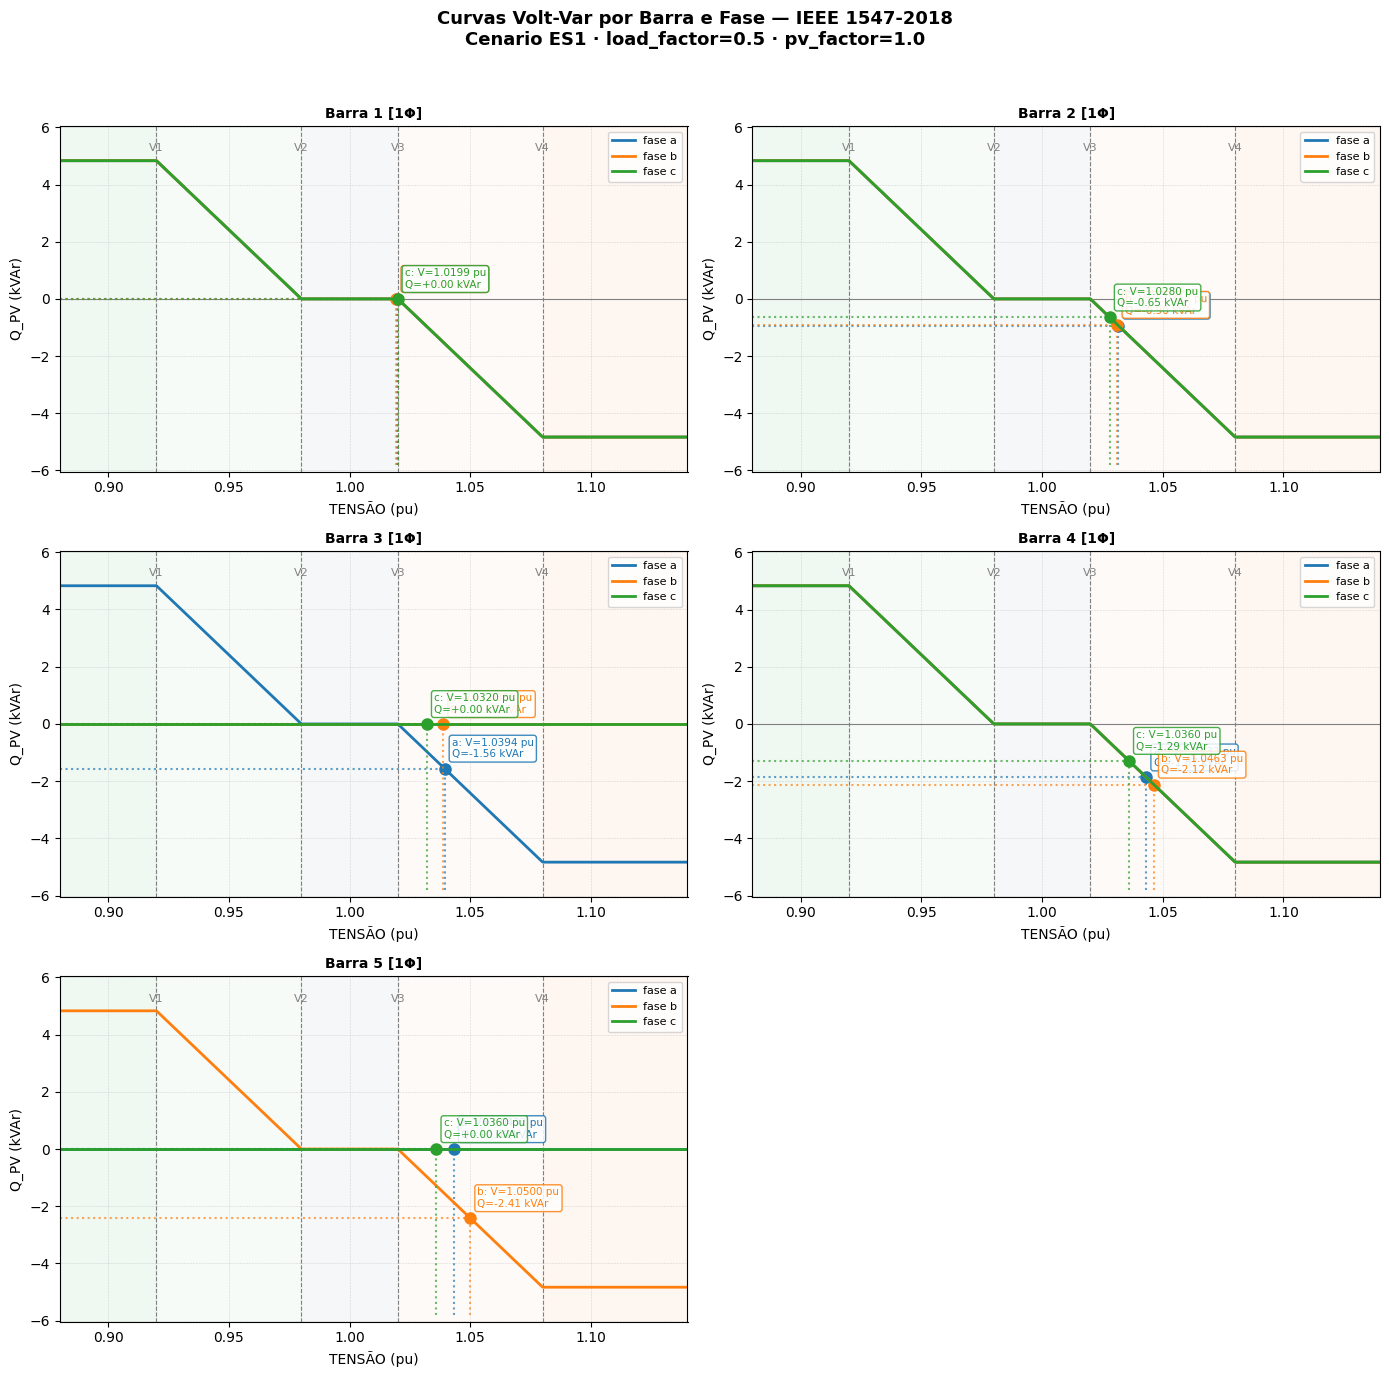

In [ ]:

# ============================================================
# PARÂMETROS DE DA CURVA VOLT-VAR
# ============================================================
V1, V2, V3, V4 = 0.92, 0.98, 1.02, 1.08

def curva_voltvar(Qmax, n_pts=500):
    V_vec = np.linspace(0.88, 1.14, n_pts)
    Q_vec = np.zeros(n_pts)

    if abs(Qmax) < 1e-12:
        return V_vec, Q_vec

    slope2 = -Qmax / (V2 - V1)
    slope4 = -Qmax / (V4 - V3)

    for k, v in enumerate(V_vec):
        if v < V1:
            Q_vec[k] = Qmax
        elif v < V2:
            Q_vec[k] = Qmax + slope2 * (v - V1)
        elif v <= V3:
            Q_vec[k] = 0.0
        elif v <= V4:
            Q_vec[k] = slope4 * (v - V3)
        else:
            Q_vec[k] = -Qmax
    return V_vec, Q_vec


datos_barras = {}

for bus in barras_bt:
    datos_barras[bus] = {}
    for ph in FASES:
        datos_barras[bus][ph] = {
            'V': np.sqrt(abs(safe_val(model.V2[bus, ph]))),
            'Q': safe_val(model.Q_PV[bus, ph], 0.0) * S_base_1f,
            'Qmax': safe_val(model.Qmax[bus, ph], 0.0) * S_base_1f,
            'tipo': CONEXAO_BARRA[bus]['tipo']
        }

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle(
    f'Curvas Volt-Var por Barra e Fase — IEEE 1547-2018\n'
    f'Cenario {linha["cenario_nome"]} · load_factor={FATOR_CARGA} · pv_factor={FATOR_PV}',
    fontsize=13, fontweight='bold', y=0.98
)

axes_flat = axes.flatten()
phase_colors = {'a': 'tab:blue', 'b': 'tab:orange', 'c': 'tab:green'}

for idx, bus in enumerate(barras_bt):
    ax = axes_flat[idx]

    # fundo das zonas
    ax.axvspan(0.88, V1, color='#d4edda', alpha=0.35)
    ax.axvspan(V1, V2, color='#d4edda', alpha=0.20)
    ax.axvspan(V2, V3, color='#e9ecef', alpha=0.40)
    ax.axvspan(V3, V4, color='#fde8d8', alpha=0.20)
    ax.axvspan(V4, 1.14, color='#fde8d8', alpha=0.35)

    for vx, lbl in [(V1,'V1'), (V2,'V2'), (V3,'V3'), (V4,'V4')]:
        ax.axvline(vx, color='gray', linewidth=0.8, linestyle='--')
        ax.text(vx, 0.95, lbl, transform=ax.get_xaxis_transform(),
                ha='center', va='top', fontsize=8, color='gray')

    ax.axhline(0, color='gray', linewidth=0.8)

    qmax_global = max(datos_barras[bus][ph]['Qmax'] for ph in FASES)

    for ph in FASES:
        d = datos_barras[bus][ph]
        V_op = d['V']
        Q_op = d['Q']
        Qmax = d['Qmax']

        V_vec, Q_vec = curva_voltvar(Qmax)

        ax.plot(V_vec, Q_vec, linewidth=2, color=phase_colors[ph], label=f'fase {ph}')
        ax.plot(V_op, Q_op, 'o', color=phase_colors[ph], markersize=8)
        ax.plot([V_op, V_op], [-1.2*qmax_global, Q_op], linestyle=':', color=phase_colors[ph], alpha=0.7)
        ax.plot([0.88, V_op], [Q_op, Q_op], linestyle=':', color=phase_colors[ph], alpha=0.7)

        ax.annotate(
            f'{ph}: V={V_op:.4f} pu\nQ={Q_op:+.2f} kVAr',
            xy=(V_op, Q_op),
            xytext=(V_op + 0.003, Q_op + 0.08*max(qmax_global, 0.1)),
            fontsize=7.5,
            color=phase_colors[ph],
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                      edgecolor=phase_colors[ph], alpha=0.85)
        )

    tipo_label = '3Φ' if CONEXAO_BARRA[bus]['tipo'] == 'three_phase' else '1Φ'
    ax.set_title(f'Barra {bus} [{tipo_label}]', fontsize=10, fontweight='bold')
    ax.set_xlim(0.88, 1.14)
    ax.set_ylim(-1.25*max(qmax_global, 0.1), 1.25*max(qmax_global, 0.1))
    ax.set_xlabel('TENSÃO (pu)')
    ax.set_ylabel('Q_PV (kVAr)')
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5)
    ax.legend(fontsize=8)

axes_flat[5].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('voltvar_curvas_3ph_desbalanceado.png', dpi=150, bbox_inches='tight')
plt.show()

# print("Gráfico salvo")